C:\Users\tsift\AppData\Local\Temp\ipykernel_740\1576806592.py:17: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])


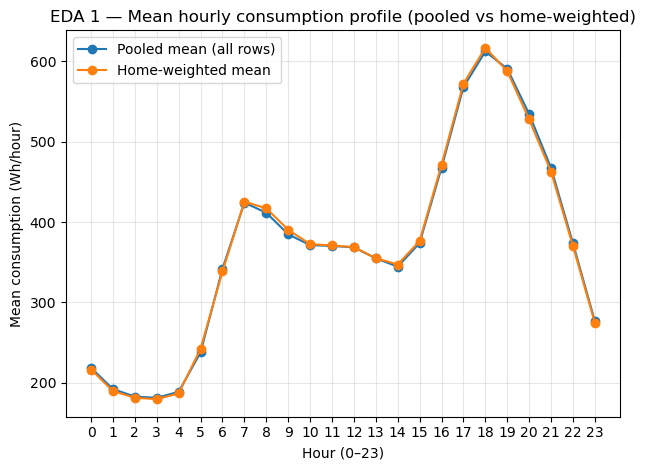

Saved: C:\IDEAL_Programming\processed\plots\eda_new\EDA_01_mean_consumption_by_hour_pooled_vs_weighted.png

EDA 2 counts:
Weekday rows: 1088052 | Weekend rows: 441298


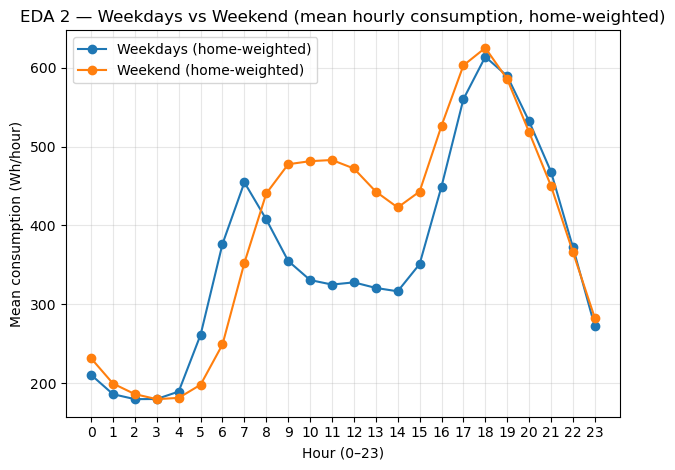

Saved: C:\IDEAL_Programming\processed\plots\eda_new\EDA_02_weekday_vs_weekend_by_hour_weighted.png

EDA 3 temp rows:
Rows before dropna: 1529350 | after: 1529350 | dropped: 0


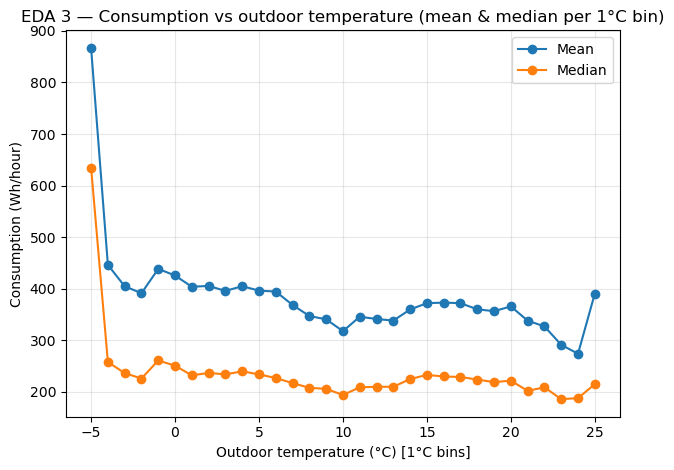

Saved: C:\IDEAL_Programming\processed\plots\eda_new\EDA_03_consumption_vs_outdoor_temp_binned_mean_median.png

EDA 4 homes per location:
 location
Edinburgh      187
Midlothian      30
EastLothian     13
WestLothian     13
Fife            11
Name: home_id, dtype: int64


C:\Users\tsift\AppData\Local\Temp\ipykernel_740\1576806592.py:180: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_loc, labels=labels, showfliers=True)


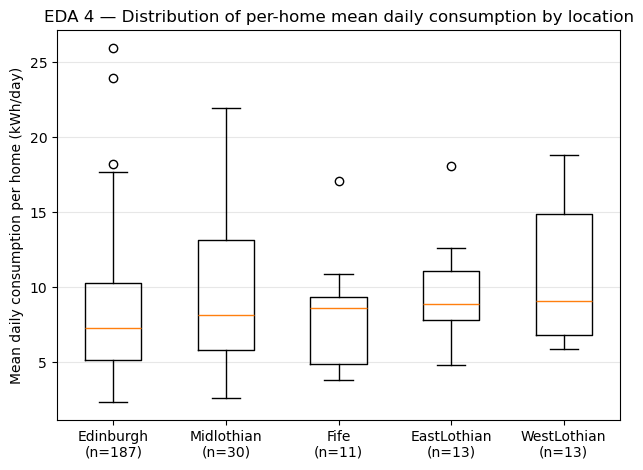


Plots saved to: C:\IDEAL_Programming\processed\plots\eda_new


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Paths
# =========================
BASE_DIR = Path("C:/IDEAL_Programming")
DATA_PATH = BASE_DIR / "processed" / "final" / "IDEAL_final_hourly_dataset.csv"

PLOTS_DIR = BASE_DIR / "processed" / "plots" / "eda_new"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# Load
# =========================
df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])

# Basic sanity checks
core_cols = ["home_id", "timestamp", "consumption_Wh", "external_temperature", "is_weekend", "location"]
missing_core = [c for c in core_cols if c not in df.columns]
if missing_core:
    raise ValueError(f"Missing required columns: {missing_core}")

df["hour"] = df["timestamp"].dt.hour
df["date"] = df["timestamp"].dt.date

# Helper: save + show
def save_show(fig_name: str):
    out = PLOTS_DIR / fig_name
    plt.tight_layout()
    plt.savefig(out, dpi=200)
    plt.show()
    print("Saved:", out)

# ==========================================================
# Plot 1 (Improved): Mean hourly profile - UNWEIGHTED vs WEIGHTED-by-home
# - Unweighted: all rows pooled (as before)
# - Weighted: compute per-home mean per hour, then average across homes
#   (each home contributes equally)
# ==========================================================
# Unweighted (pooled)
hourly_mean_unw = df.groupby("hour")["consumption_Wh"].mean().sort_index()

# Weighted-by-home (equal weight per home)
hourly_mean_by_home = (
    df.groupby(["home_id", "hour"])["consumption_Wh"].mean()
      .reset_index()
      .groupby("hour")["consumption_Wh"].mean()
      .sort_index()
)

plt.figure()
plt.plot(hourly_mean_unw.index, hourly_mean_unw.values, marker="o", label="Pooled mean (all rows)")
plt.plot(hourly_mean_by_home.index, hourly_mean_by_home.values, marker="o", label="Home-weighted mean")
plt.xlabel("Hour (0–23)")
plt.ylabel("Mean consumption (Wh/hour)")
plt.title("EDA 1 — Mean hourly consumption profile (pooled vs home-weighted)")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.legend()
save_show("EDA_01_mean_consumption_by_hour_pooled_vs_weighted.png")

# ==========================================================
# Plot 2 (Improved): Weekday vs Weekend hourly profile (home-weighted)
# - Avoid bias from homes with more data
# - Also prints row counts used
# ==========================================================
wd_df = df[df["is_weekend"] == 0].copy()
we_df = df[df["is_weekend"] == 1].copy()

print("\nEDA 2 counts:")
print("Weekday rows:", len(wd_df), "| Weekend rows:", len(we_df))

wd = (
    wd_df.groupby(["home_id", "hour"])["consumption_Wh"].mean()
        .reset_index()
        .groupby("hour")["consumption_Wh"].mean()
        .sort_index()
)
we = (
    we_df.groupby(["home_id", "hour"])["consumption_Wh"].mean()
        .reset_index()
        .groupby("hour")["consumption_Wh"].mean()
        .sort_index()
)

plt.figure()
plt.plot(wd.index, wd.values, marker="o", label="Weekdays (home-weighted)")
plt.plot(we.index, we.values, marker="o", label="Weekend (home-weighted)")
plt.xlabel("Hour (0–23)")
plt.ylabel("Mean consumption (Wh/hour)")
plt.title("EDA 2 — Weekdays vs Weekend (mean hourly consumption, home-weighted)")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.legend()
save_show("EDA_02_weekday_vs_weekend_by_hour_weighted.png")

# ==========================================================
# Plot 3 (Improved): Consumption vs outdoor temperature (1°C bins)
# - Adds bin sample counts
# - Uses median line (robust) + mean line (for comparability)
# - Drops NaNs explicitly and reports drop rate
# ==========================================================
temp = df[["external_temperature", "consumption_Wh"]].copy()
before = len(temp)
temp = temp.dropna()
after = len(temp)

print("\nEDA 3 temp rows:")
print("Rows before dropna:", before, "| after:", after, f"| dropped: {before - after}")

temp["temp_bin"] = temp["external_temperature"].round(0).astype(int)

temp_stats = (
    temp.groupby("temp_bin")["consumption_Wh"]
        .agg(mean="mean", median="median", count="count")
        .reset_index()
        .sort_values("temp_bin")
)

plt.figure()
plt.plot(temp_stats["temp_bin"], temp_stats["mean"], marker="o", label="Mean")
plt.plot(temp_stats["temp_bin"], temp_stats["median"], marker="o", label="Median")

# annotate sparse bins (optional): mark bins with very few samples
sparse = temp_stats[temp_stats["count"] < 50]
if len(sparse) > 0:
    for _, r in sparse.iterrows():
        plt.text(r["temp_bin"], r["mean"], f"n={int(r['count'])}", fontsize=8)

plt.xlabel("Outdoor temperature (°C) [1°C bins]")
plt.ylabel("Consumption (Wh/hour)")
plt.title("EDA 3 — Consumption vs outdoor temperature (mean & median per 1°C bin)")
plt.grid(True, alpha=0.3)
plt.legend()
save_show("EDA_03_consumption_vs_outdoor_temp_binned_mean_median.png")

# ==========================================================
# Plot 4 (Improved): Mean daily kWh per home by location (boxplot)
# - Keeps fliers ON (showfliers=True) for true EDA
# - Reports number of homes per location
# - Optionally orders locations by median
# ==========================================================
daily_home = (
    df.groupby(["home_id", "location", "date"])["consumption_Wh"]
      .sum()
      .reset_index()
)

mean_daily_by_home = (
    daily_home.groupby(["home_id", "location"])["consumption_Wh"]
              .mean()
              .reset_index()
)

mean_daily_by_home["mean_daily_kWh"] = mean_daily_by_home["consumption_Wh"] / 1000.0

# count homes per location
home_counts = mean_daily_by_home.groupby("location")["home_id"].nunique().sort_values(ascending=False)
print("\nEDA 4 homes per location:\n", home_counts)

# order locations by median consumption for nicer plot
loc_order = (
    mean_daily_by_home.groupby("location")["mean_daily_kWh"]
                      .median()
                      .sort_values()
                      .index
                      .tolist()
)

data_by_loc = [
    mean_daily_by_home.loc[mean_daily_by_home["location"] == loc, "mean_daily_kWh"].values
    for loc in loc_order
]

labels = [f"{loc}\n(n={home_counts.get(loc, 0)})" for loc in loc_order]

plt.figure()
plt.boxplot(data_by_loc, labels=labels, showfliers=True)
plt.ylabel("Mean daily consumption per home (kWh/day)")
plt.title("EDA 4 — Distribution of per-home mean daily consumption by location")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "EDA_04_mean_daily_kWh_by_location_boxplot_showfliers.png", dpi=200)
plt.show()

print("\nPlots saved to:", PLOTS_DIR)
